# Исследование фичей: погода

## Вопрос

---

Как погода связана со спросом и какие погодные фичи реально нужны? Конкретно:
1. не избыточны ли `temperature_c` и `perceived_temperature_c`;
2. линейна ли связь температуры со спросом (нужна ли деревьям);
3. насколько давят осадки и есть ли взаимодействие `погода × час`.

> **Дисциплина данных.** Анализ описательный, на **train** (val/test в сейфе) — для понимания процесса.
> Отбор фич и модели идёт на validation в [eda_and_modeling.ipynb](eda_and_modeling.ipynb), test нетронут до финала.
> Источник — `hourly_by_location.csv` (выход пайплайна).

## Setup

---

Читаем `hourly_by_location`, агрегируем до часа (погода одинакова по локациям в час), берём train.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PROCESSED = Path("../data/processed")
fd = pd.read_csv(DATA_PROCESSED / "hourly_by_location.csv", parse_dates=["datetime_hourly"])

WEATHER = ["conditions", "temperature_c", "perceived_temperature_c", "humidity", "windspeed_kmh"]
hourly = (fd.groupby("datetime_hourly")
          .agg(total=("total_rentals", "sum"), hour=("hour_of_day", "first"),
               **{w: (w, "first") for w in WEATHER})
          .reset_index())

ts = np.sort(hourly["datetime_hourly"].unique())
train = hourly[hourly["datetime_hourly"] < ts[int(len(ts) * 0.70)]]
print(f"train часов: {len(train)}")

train часов: 12165


## 1. Коллинеарность температур

---

`temperature_c` и `perceived_temperature_c` — два измерения одного. Если дублируют друг друга, одна лишняя.

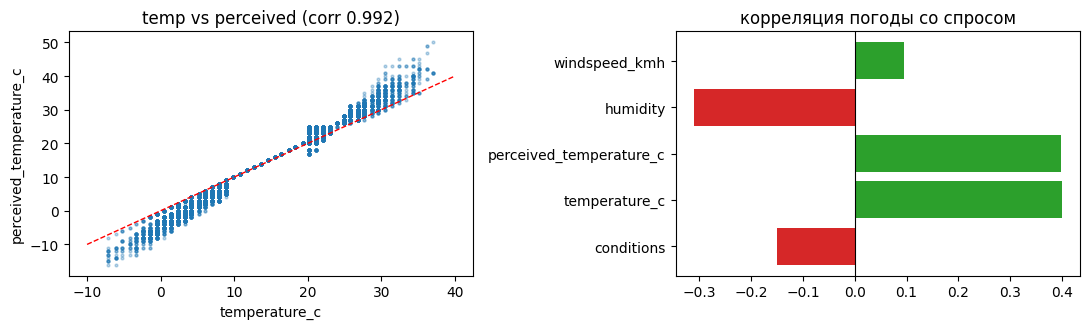

temp vs perceived: corr 0.9918,  |разница| ≤ 12.9°C  (в среднем -0.2)


In [2]:
corr = train["temperature_c"].corr(train["perceived_temperature_c"])
diff = train["perceived_temperature_c"] - train["temperature_c"]
wcorr = train[["total"] + WEATHER].corr()["total"].drop("total")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].scatter(train["temperature_c"], train["perceived_temperature_c"], s=4, alpha=0.3)
ax[0].plot([-10, 40], [-10, 40], "r--", lw=1)
ax[0].set_xlabel("temperature_c"); ax[0].set_ylabel("perceived_temperature_c")
ax[0].set_title(f"temp vs perceived (corr {corr:.3f})")
ax[1].barh(wcorr.index, wcorr.values, color=["#d62728" if v < 0 else "#2ca02c" for v in wcorr])
ax[1].axvline(0, color="black", lw=0.8); ax[1].set_title("корреляция погоды со спросом")
plt.tight_layout(); plt.show()

print(f"temp vs perceived: corr {corr:.4f},  |разница| ≤ {diff.abs().max():.1f}°C  (в среднем {diff.mean():+.1f})")

### Наблюдения

- `perceived_temperature_c` почти совпадает с `temperature_c`: **corr 0.99**, в среднем нулевая разница (изредка до ~13°C), и со спросом корреляция такая же (**0.40**). Выглядит лишней — но решает не корреляция, а эксперимент: ablation [#5](eda_and_modeling.ipynb) показал, что убирать её **нельзя**. Те ~1% расхождения (поправка на ветер и влажность) дерево использует.
- Влажность — заметный минус (−0.31), ветер почти ноль (0.09), `conditions` слабый минус (−0.15).

## 2. Температура → спрос

---

Линейна ли связь, или есть нелинейность (горб на комфортной температуре, спад в жару)?

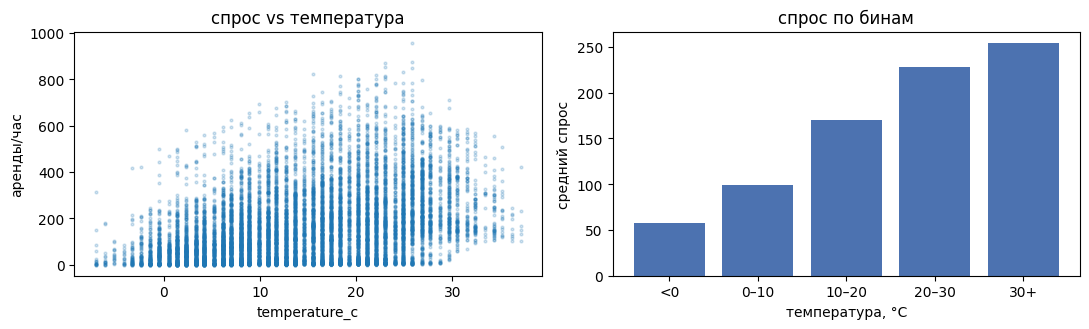

tbin
<0        57.0
0–10      99.0
10–20    170.0
20–30    228.0
30+      254.0


In [3]:
bins = [-100, 0, 10, 20, 30, 100]; labels = ["<0", "0–10", "10–20", "20–30", "30+"]
by_temp = (train.assign(tbin=pd.cut(train["temperature_c"], bins=bins, labels=labels))
           .groupby("tbin", observed=True)["total"].mean())

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].scatter(train["temperature_c"], train["total"], s=4, alpha=0.2)
ax[0].set_xlabel("temperature_c"); ax[0].set_ylabel("аренды/час"); ax[0].set_title("спрос vs температура")
ax[1].bar(by_temp.index.astype(str), by_temp.values, color="#4c72b0")
ax[1].set_xlabel("температура, °C"); ax[1].set_ylabel("средний спрос"); ax[1].set_title("спрос по бинам")
plt.tight_layout(); plt.show()
print(by_temp.round(0).to_string())

### Наблюдения

- Спрос **растёт с температурой почти равномерно** (от ~57/час при <0°C до ~254 при 30+°C), с лёгким насыщением сверху. Разворота в жару нет — в Вашингтоне температуры не настолько экстремальны (30+°C всего ~340 часов).
- Связь близка к линейной (corr 0.40), поэтому её ловит уже baseline; большого нелинейного выигрыша по температуре ждать не стоит.
- Важная оговорка: это связь «как есть». Температура переплетена с сезоном и часом (тепло = лето + день), так что часть «эффекта температуры» на деле — это время.

## 3. Осадки и взаимодействие с часом

---

`conditions` (0 clear … 3 heavy_rain): давят ли осадки спрос, и одинаково ли по часам?

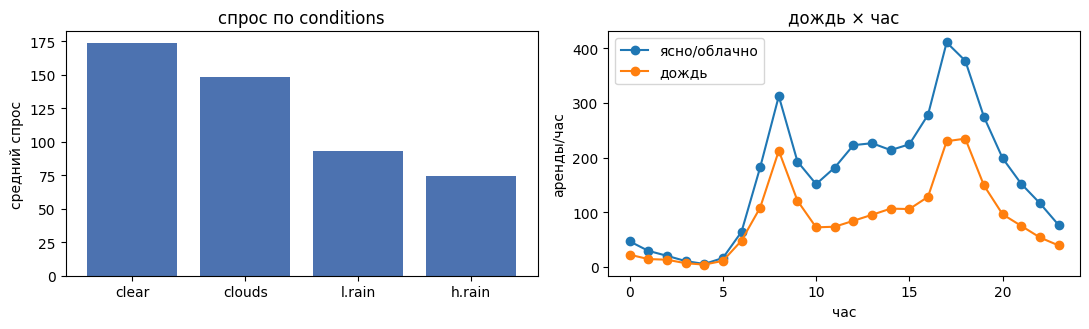

             mean  count
conditions              
0           174.0   7937
1           148.0   3145
2            93.0   1080
3            74.0      3


In [4]:
by_cond = train.groupby("conditions")["total"].agg(["mean", "count"])
prof = (train.assign(rain=(train["conditions"] >= 2).astype(int))
        .groupby(["rain", "hour"])["total"].mean().unstack("rain"))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].bar(by_cond.index, by_cond["mean"], color="#4c72b0")
ax[0].set_xticks([0, 1, 2, 3]); ax[0].set_xticklabels(["clear", "clouds", "l.rain", "h.rain"])
ax[0].set_ylabel("средний спрос"); ax[0].set_title("спрос по conditions")
ax[1].plot(prof.index, prof[0], marker="o", label="ясно/облачно")
ax[1].plot(prof.index, prof[1], marker="o", label="дождь")
ax[1].set_xlabel("час"); ax[1].set_ylabel("аренды/час"); ax[1].set_title("дождь × час"); ax[1].legend()
plt.tight_layout(); plt.show()
print(by_cond.round(0).to_string())

### Наблюдения

- У `conditions` чёткий ступенчатый эффект: clear 174 → clouds 148 → light_rain 93 (heavy_rain 74, но всего 3 часа — ненадёжно).
- Дождь снижает спрос на 30–58%, сильнее всего днём (в 13ч −58%). Часы пик устойчивее (8ч −32%, 17ч −44%): в дождь на работу едут, а на прогулку — нет. Это реальное взаимодействие `погода × час`.
- Но поверх часа и сезона добавка маленькая: ablation #2 в [eda_and_modeling](eda_and_modeling.ipynb) дал всего +0.002 R². Дождь связан со временем, а его модель уже учитывает.

## Выводы

---

- **`perceived_temperature_c` — corr 0.99 с `temperature_c`**, выглядит лишней. Но ablation [#5](eda_and_modeling.ipynb) сказал обратное: **оставляем**. У HGB её удаление роняет R² с 0.892 до 0.879; те ~1% расхождения (поправка на ветер и влажность) несут сигнал. Решила не корреляция, а тест.
- **Температура и спрос связаны почти линейно** (рост, лёгкое насыщение, без разворота) — это ловит уже baseline, большого выигрыша по температуре нет.
- **Осадки реально снижают спрос** (−30…−58%, днём сильнее), есть взаимодействие `дождь × час`. Но `conditions` связан со временем, поэтому поверх часа добавляет мало (ablation #2).
- Влажность — слабый минус, ветер — почти ноль.

**Для модели (доводы разной силы):**
- `temperature_c` + `perceived_temperature_c` — оставляем **уверенно**, по тесту: несмотря на corr 0.99, удаление perceived роняет R² 0.892 → 0.879 (#5).
- `conditions` (и `дождь × час`) — оставляем **с натяжкой**: эффект реальный и понятный, но поверх часа/сезона добавляет лишь +0.002 R² (#2). Берём как почти бесплатное для дерева, а не как сильный признак.
- `humidity` — слабый минус, `windspeed_kmh` — почти ноль: держим, вреда нет.